---
---
---

# Banned But Not Forgotten — Remaining Tasks & Starter Code

## Quick Fixes (Before Anything Else)

Two files were missing from the last pipeline run. Re-run the pipeline once these are added:

1.  **`election_results.xlsx`** — extract from `2024_Presidential_Election_Results.zip` and place in the pipeline folder. Without this, all political lean data shows `?`.
2.  **`full_book_details.csv`** — Violet's expanded Goodreads file. Without this, the genre supplement doesn't generate (category coverage drops from 81% → 80%).

Then re-run:

``` bash
python analysis_pipeline.py


All outputs in `outputs/` will update with correct political data.

------------------------------------------------------------------------

## What the Data Now Shows (Updated Findings)

With 3,463 Google Trends titles (up from 634) and 7,293 Goodreads books (up from 256):

| Finding | Status | Evidence |
|------------------------|----------------------|---------------------------|
| Bans on average REDUCE search interest | **Now significant** (p=0.017) | Mean change = -6.7%, Cohen's d = -0.05 |
| Streisand Effect depends on pre-ban popularity | **Highly significant** (p \< 0.000001) | η² = 0.116 (large), 8 post-hoc pairs significant |
| Content category does NOT matter | Confirmed null | KW p=0.95, χ² p=0.97 — spike rates \~48% for all categories |
| Ban frequency does NOT predict spikes | **Flipped to null** | ρ=0.007, p=0.73 (was significant with smaller sample) |

------------------------------------------------------------------------

## Violet — Data Visualization & Analysis

### Deliverables

1.  Streisand Effect by popularity tier (THE key chart)
2.  Before/after scatter plot
3.  Top 10 Streisand / Top 10 Suppressed bar chart
4.  Challenge reason distribution
5.  Goodreads engagement vs banning scatter

### Source Files

-   `outputs/google_trends_cleaned.csv` — 2,440 rows with before/after search data
-   `outputs/goodreads_cleaned.csv` — 7,293 rows with ratings and engagement
-   `outputs/title_categories.csv` — 8,360 rows with challenge reasons
-   `outputs/categories_x_google_trends.csv` — merged categories + trends

### Setup

bash
pip install pandas matplotlib seaborn numpy


### Tutorial Videos

-   Matplotlib basics: <https://www.youtube.com/watch?v=UO98lJQ3QGI>
-   Seaborn statistical visualizations: <https://www.youtube.com/watch?v=6GUZXDef2U0>
-   Box plots and grouped bars in seaborn: <https://www.youtube.com/watch?v=IIwRMsOqc20>
-   Customizing matplotlib for publication: <https://www.youtube.com/watch?v=DAQNHzOcO5A>

### VIZ 1: Streisand Effect by Popularity Tier (most important chart)

This is the headline visualization. Show that moderately popular books spike, low-interest books get suppressed, and very popular books barely move.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


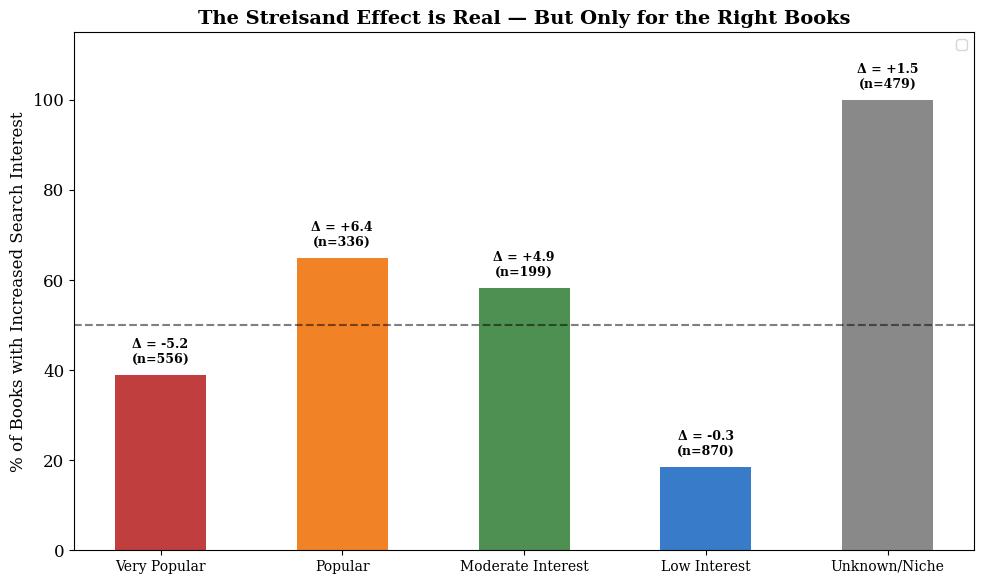

/var/folders/6c/hjkys9j9037grwvjg6l8fl2m0000gq/T/ipykernel_10858/1931541386.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gt, x='pre_ban_popularity', y='spike_magnitude',


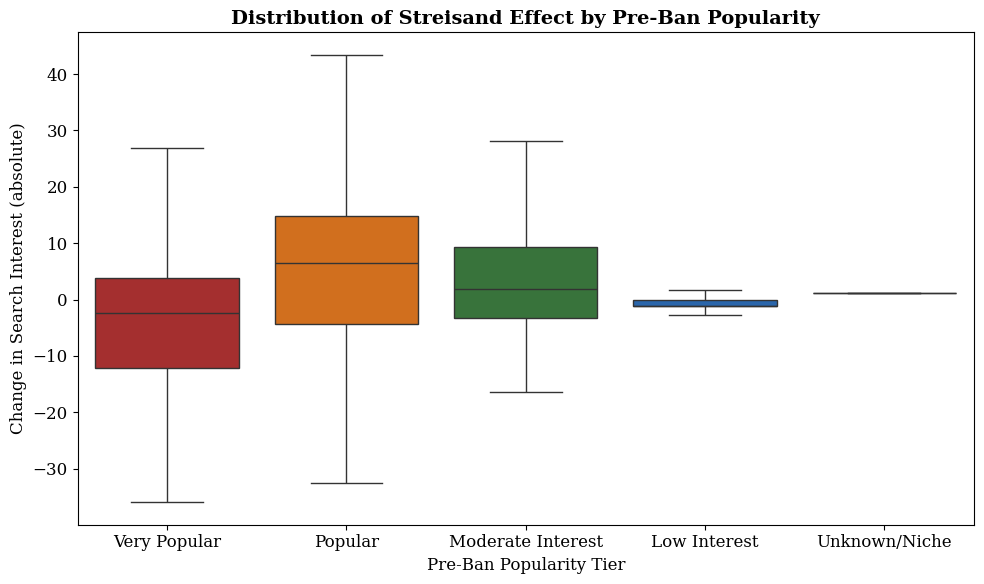

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
import seaborn as sns
import numpy as np

gt = pd.read_csv('outputs/google_trends_cleaned.csv')

# --- Option A: Grouped bar chart (spike rate + mean magnitude) ---

tier_order = ['Very Popular', 'Popular', 'Moderate Interest', 'Low Interest', 'Unknown/Niche']
tier_stats = gt.groupby('pre_ban_popularity').agg(
    spike_rate=('searches_increased', 'mean'),
    mean_spike=('spike_magnitude', 'mean'),
    n=('book_title', 'size')
).reindex(tier_order)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Spike rate bars
x = np.arange(len(tier_order))
colors = ['#b71c1c',
                 '#ef6c00',
                 '#2e7d32',
                 '#1565c0',
                 '#757575']
bars = ax1.bar(x, tier_stats['spike_rate'] * 100, width=0.5, color=colors, alpha=0.85)

# Add mean spike as text annotation on each bar
for i, (rate, spike, n) in enumerate(zip(tier_stats['spike_rate'], tier_stats['mean_spike'], tier_stats['n'])):
    ax1.text(i, rate * 100 + 2, f'Δ = {spike:+.1f}\n(n={n})',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(tier_order, fontsize=10)
ax1.set_ylabel('% of Books with Increased Search Interest', fontsize=12)
ax1.set_title('The Streisand Effect is Real — But Only for the Right Books', fontsize=14, fontweight='bold') #right books being niche 
ax1.axhline(50, color='black', linestyle='--', alpha=0.5)
ax1.set_ylim(0, 115)
ax1.legend(fontsize=10)

plt.tight_layout()
plt.savefig('viz_popularity_tier.png', dpi=200, bbox_inches='tight')
plt.show()

# --- Option B: Box plot (shows full distribution) ---

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=gt, x='pre_ban_popularity', y='spike_magnitude',
            order=tier_order, palette=colors, ax=ax, showfliers=False)
#ax.axhline(0, color='red', linestyle='--', alpha=0.6)
ax.set_xlabel('Pre-Ban Popularity Tier', fontsize=12)
ax.set_ylabel('Change in Search Interest (absolute)', fontsize=12)
ax.set_title('Distribution of Streisand Effect by Pre-Ban Popularity', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_popularity_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()


### VIZ 2: Before/After Scatter Plot

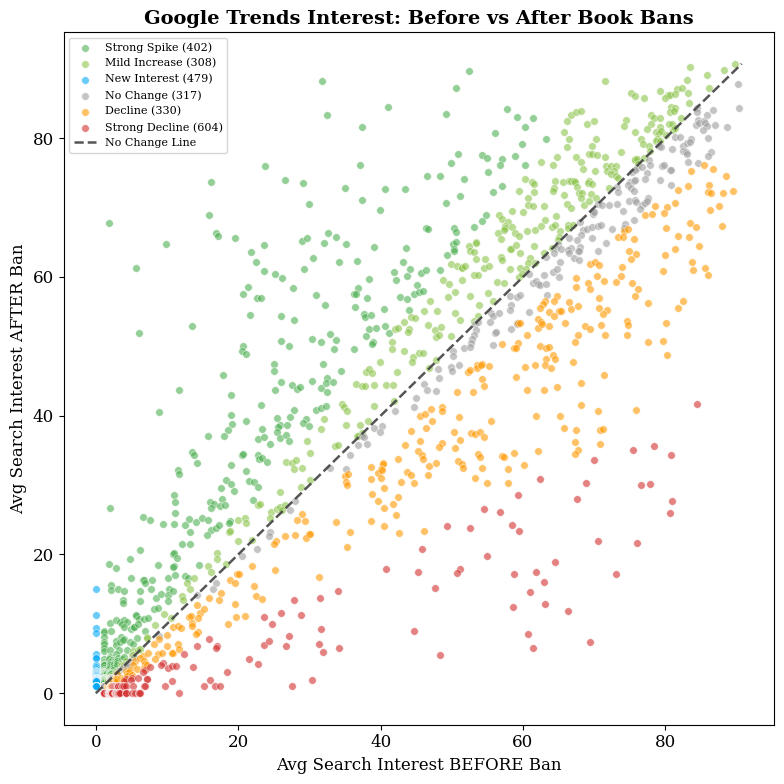

In [27]:
gt = pd.read_csv('outputs/google_trends_cleaned.csv')

fig, ax = plt.subplots(figsize=(8, 8))

# Color by Streisand category
cat_colors = {
    'Strong Spike': '#4caf50',
    'Mild Increase': '#8bc34a',
    'New Interest': '#03a9f4',
    'No Change': '#9e9e9e',
    'Decline': '#ff9800',
    'Strong Decline': '#d32f2f',
}

for cat, color in cat_colors.items():
    subset = gt[gt['streisand_category'] == cat]
    ax.scatter(subset['avg_search_before'], subset['avg_search_after'],
               c=color, label=f'{cat} ({len(subset)})', alpha=0.6, s=30, edgecolors='white', linewidth=0.5)

# Diagonal = no change line
max_val = max(gt['avg_search_before'].max(), gt['avg_search_after'].max())
ax.plot([0, max_val], [0, max_val],
        linestyle='--',
        color='#424242',
        linewidth=1.8,
        alpha=0.9,
        label='No Change Line')

ax.set_xlabel('Avg Search Interest BEFORE Ban', fontsize=12)
ax.set_ylabel('Avg Search Interest AFTER Ban', fontsize=12)
ax.set_title('Google Trends Interest: Before vs After Book Bans', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('viz_before_after_scatter.png', dpi=200, bbox_inches='tight')
plt.show()


### VIZ 3: Top 10 Streisand Effect / Top 10 Suppressed

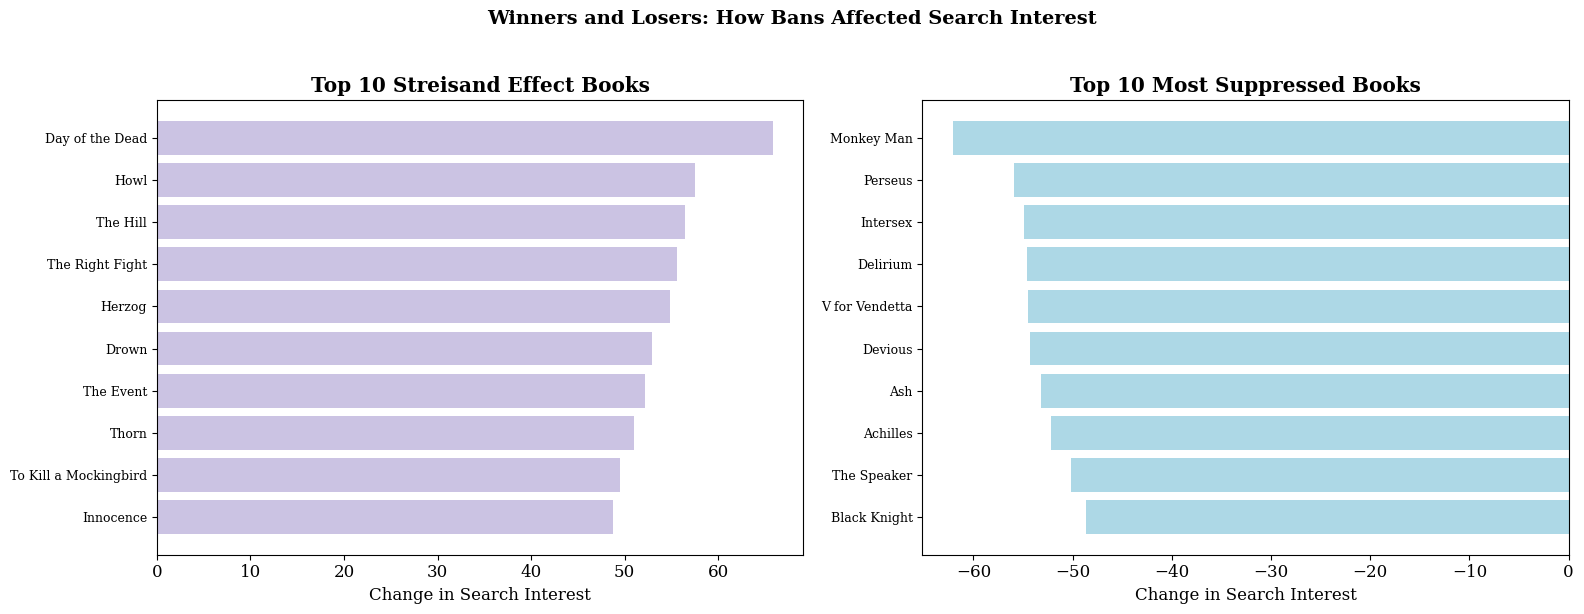

In [63]:
gt = pd.read_csv('outputs/google_trends_cleaned.csv')

# Top 10 biggest spikes (by spike_magnitude)
top_spike = gt.nlargest(10, 'spike_magnitude')[['book_title', 'spike_magnitude', 'avg_search_before', 'avg_search_after']]
# Top 10 biggest declines
top_decline = gt.nsmallest(10, 'spike_magnitude')[['book_title', 'spike_magnitude', 'avg_search_before', 'avg_search_after']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Spike side
ax1.barh(range(len(top_spike)), top_spike['spike_magnitude'], color='#CBC3E3')
ax1.set_yticks(range(len(top_spike)))
ax1.set_yticklabels([t[:40] for t in top_spike['book_title']], fontsize=9)
ax1.set_xlabel('Change in Search Interest')
ax1.set_title('Top 10 Streisand Effect Books', fontweight='bold')
ax1.invert_yaxis()

# Decline side
ax2.barh(range(len(top_decline)), top_decline['spike_magnitude'], color='#ADD8E6')
ax2.set_yticks(range(len(top_decline)))
ax2.set_yticklabels([t[:40] for t in top_decline['book_title']], fontsize=9)
ax2.set_xlabel('Change in Search Interest')
ax2.set_title('Top 10 Most Suppressed Books', fontweight='bold')
ax2.invert_yaxis()

plt.suptitle('Winners and Losers: How Bans Affected Search Interest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_top10_both.png', dpi=200, bbox_inches='tight')
plt.show()


### VIZ 4: Challenge Reason Distribution

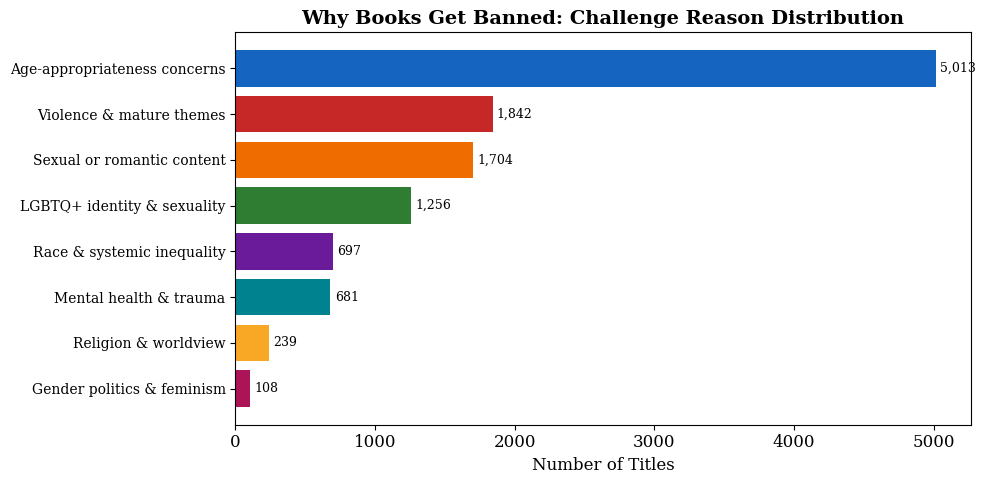

In [31]:
cats = pd.read_csv('outputs/title_categories.csv')

# Explode semicolon-separated reasons
reasons = cats['challenge_reasons'].dropna().str.split('; ').explode()
reasons = reasons[reasons != '']
reason_counts = reasons.value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1565c0', '#c62828', '#ef6c00', '#2e7d32', '#6a1b9a', '#00838f', '#f9a825', '#ad1457']
bars = ax.barh(range(len(reason_counts)), reason_counts.values, color=colors[:len(reason_counts)])
ax.set_yticks(range(len(reason_counts)))
ax.set_yticklabels(reason_counts.index, fontsize=10)
ax.set_xlabel('Number of Titles', fontsize=12)
ax.set_title('Why Books Get Banned: Challenge Reason Distribution', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add count labels
for i, v in enumerate(reason_counts.values):
    ax.text(v + 30, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz_challenge_reasons.png', dpi=200, bbox_inches='tight')
plt.show()


### VIZ 5: Goodreads Engagement vs Banning

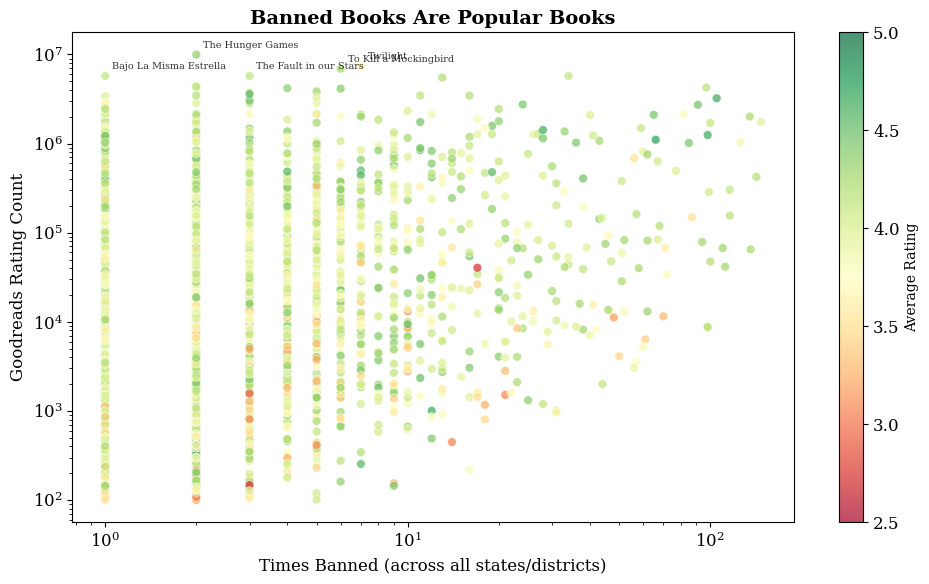

In [33]:

gr = pd.read_csv('outputs/goodreads_cleaned.csv')

# Filter to good quality books with ban data
good = gr[(gr['data_quality'] == 'Good') & (gr['total_ban_instances'].notna())].copy()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(good['total_ban_instances'], good['rating_count'],
                     c=good['avg_rating'], cmap='RdYlGn', s=40, alpha=0.7,
                     edgecolors='white', linewidth=0.5, vmin=2.5, vmax=5.0)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Times Banned (across all states/districts)', fontsize=12)
ax.set_ylabel('Goodreads Rating Count', fontsize=12)
ax.set_title('Banned Books Are Popular Books', fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Average Rating', fontsize=10)

# Annotate a few notable books
for _, row in good.nlargest(5, 'rating_count').iterrows():
    ax.annotate(row['book_title'][:25], (row['total_ban_instances'], row['rating_count']),
                fontsize=7, alpha=0.8, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('viz_goodreads_vs_banning.png', dpi=200, bbox_inches='tight')
plt.show()


### VIZ 5.2: Goodreads Engagement vs Banning

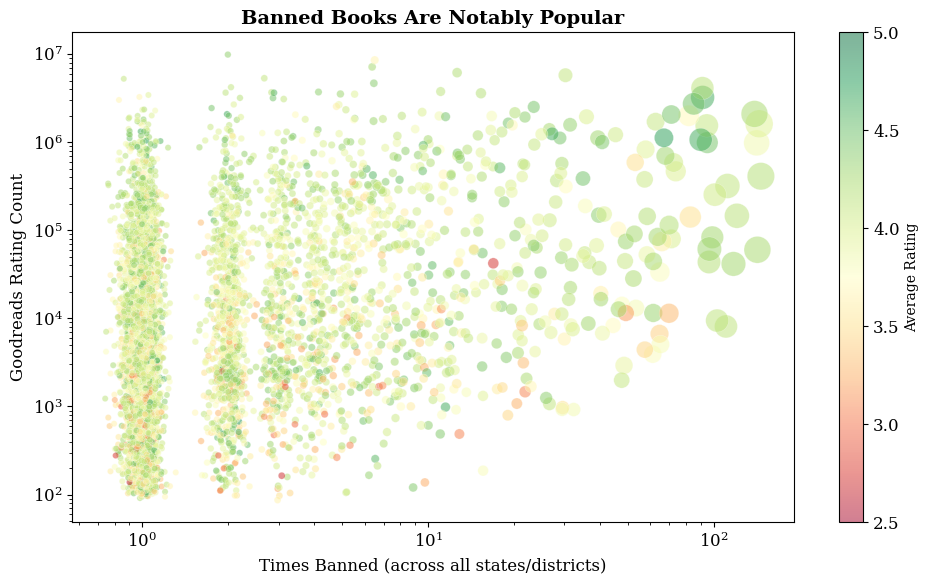

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
gr = pd.read_csv('outputs/goodreads_cleaned.csv')

good = gr[(gr['data_quality'] == 'Good') & 
          (gr['total_ban_instances'].notna())].copy()

# -----------------------------
# Log-safe jitter (multiplicative)
# -----------------------------
np.random.seed(42)

x_jitter = good['total_ban_instances'] * np.random.normal(1, 0.08, len(good))
y_jitter = good['rating_count'] * np.random.normal(1, 0.08, len(good))

# -----------------------------
# Scale size by bans
# -----------------------------
min_size = 20
max_size = 400

scaled_sizes = min_size + (
    (good['total_ban_instances'] - good['total_ban_instances'].min()) /
    (good['total_ban_instances'].max() - good['total_ban_instances'].min())
) * (max_size - min_size)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    x_jitter,
    y_jitter,
    c=good['avg_rating'],
    cmap='RdYlGn',
    s=scaled_sizes,
    alpha=0.5,
    edgecolors='white',
    linewidth=0.3,
    vmin=2.5,
    vmax=5.0
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Times Banned (across all states/districts)', fontsize=12)
ax.set_ylabel('Goodreads Rating Count', fontsize=12)
ax.set_title('Banned Books Are Notably Popular', fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Average Rating', fontsize=10)

plt.tight_layout()
plt.show()